# GPS Mining Diagnostic Agent — Demo

This notebook shows what the agent does for one load zone, using only GPS-derived
cycle data (no payload / fuel / dispatch / shovel data).

Pipeline: **cycles → attribution → decision (Theory of Constraints) → recommendation → LLM brief.**

To re-run it, place `cycles_all_months.csv` in the repo `data/` folder (it is git-ignored).
The outputs below are already saved, so you can read the results without running anything.
See `PROJECT_OVERVIEW.md` for the full write-up.

In [1]:
import sys, os
sys.path.append(os.path.dirname(os.path.abspath("__file__")) if "__file__" in globals() else ".")
import matplotlib.pyplot as plt
from agent_diagnose import diagnose, report
%matplotlib inline

## 1. Run the agent on the BN load zone (25559)

`diagnose()` runs perception + attribution + capacity + decision + recommendation and
returns a structured result. `report()` prints it.

In [2]:
dx = diagnose(25559)
print(report(dx))

DIAGNOSIS — BN load (Баруун наран /Зүүн/)  (zone 25559, 2025-11)
THROUGHPUT : 80.6 loads/day  |  22 trucks x 3.66 cyc  |  best day 109
CAPACITY   : shovel 7.3 loads/h x 22h = ceiling 160/day  |  utilisation 50%  |  dump p90 7.0/h
CYCLE      : 222.1 min (load svc 16 · ff-haul 60 · ff-return 50)

LOST TIME (recoverable truck-h/month, UPPER BOUND, total 9371):
   idle_stand      5580 h  (60%)
   return_road     1567 h  (17%)
   load_queue       984 h  (10%)
   haul_road        625 h  ( 7%)
   dump             615 h  ( 7%)

CONSTRAINT : binding NOW = TRUCK IDLE + ARRIVAL BUNCHING
             cut idle/de-bunch -> 131/day ; + fix roads -> 160/day ; ceiling = shovel (loading)

RECOMMENDATIONS (prioritised pointers, not validated prescriptions):
  #1  Smooth arrivals + cut standing time (dispatch / headway control)
       why   : de-bunch convoys so trucks meet the shovel evenly; overlap shift changes; in-field refuel; reduce inter-cycle parking
       effect: 81 -> 131 loads/day (+62%)
     

## 2. Attribution — where the recoverable time goes

For each part of the cycle we compare the time to the best level the fleet actually reaches
(a low percentile). The extra time is "recoverable" and goes to a named cause bucket.
These are **upper bounds**.

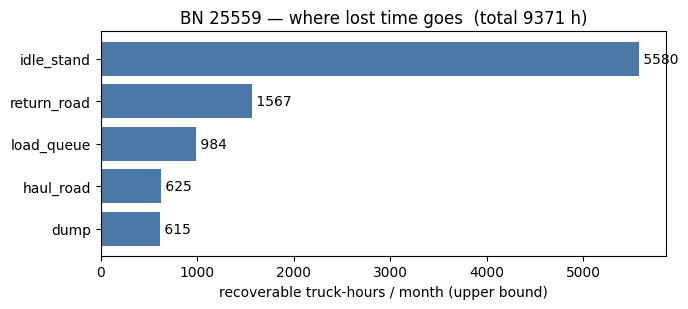

In [3]:
b = dx['attribution']['recoverable_truck_h']
items = sorted(b.items(), key=lambda x: x[1])
labels = [k for k, _ in items]
vals = [v for _, v in items]
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(labels, vals, color='#4c78a8')
ax.set_xlabel('recoverable truck-hours / month (upper bound)')
ax.set_title(f"BN {dx['zone_id']} — where lost time goes  (total {dx['attribution']['total_truck_h']} h)")
for i, v in enumerate(vals):
    ax.text(v, i, f' {v}', va='center')
plt.tight_layout(); plt.show()

## 3. Capacity and the binding constraint (Theory of Constraints)

We measure the shovel service rate from the data and compute the throughput ceiling.
Then we test what-if: removing a bucket's excess raises throughput only until it hits the
shovel ceiling. This tells us **what actually binds** and in what order to act.

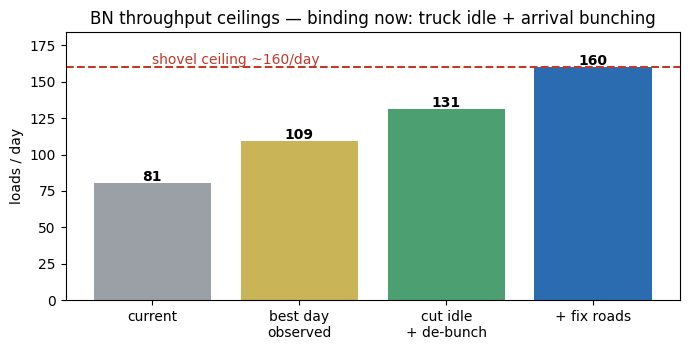

In [4]:
d = dx['decision']; t = dx['throughput']
steps = [('current', t['loads_day']),
         ('best day\nobserved', t['best_day']),
         ('cut idle\n+ de-bunch', d['supply_cut_idle']),
         ('+ fix roads', d['ceiling_with_road'])]
labels = [s[0] for s in steps]; vals = [s[1] for s in steps]
colors = ['#9aa0a6', '#c9b458', '#4c9f70', '#2b6cb0']
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.bar(labels, vals, color=colors)
ax.axhline(d['shovel_ceiling'], ls='--', color='#c0392b')
ax.text(0, d['shovel_ceiling'] + 2, f"shovel ceiling ~{d['shovel_ceiling']}/day", color='#c0392b')
ax.set_ylabel('loads / day')
ax.set_title(f"BN throughput ceilings — binding now: {d['binding_now']}")
for i, v in enumerate(vals):
    ax.text(i, v + 1.5, f'{v:.0f}', ha='center', fontweight='bold')
ax.set_ylim(0, d['shovel_ceiling'] * 1.15)
plt.tight_layout(); plt.show()

## 4. The same code gives a different diagnosis (Middling 25385)

This is the key check that the method is a real diagnostic, not a hard-coded answer.
BN has a long 34 km haul and is idle/road-bound; Middling has a short in-pit cycle and is
shovel-bound. Same function, different prescription.

In [5]:
import pandas as pd
dm = diagnose(25385)

def summ(z):
    dd, cc, tt = z['decision'], z['capacity'], z['throughput']
    top = max(z['attribution']['recoverable_truck_h'].items(), key=lambda x: x[1])[0]
    return {'loads/day': tt['loads_day'],
            'trucks': tt['trucks'],
            'full cycle (min)': z['cycle']['full_cycle_min'],
            'shovel utilisation': f"{cc['utilisation']*100:.0f}%",
            'binding now': dd['binding_now'],
            'top lost-time bucket': top,
            'does fixing roads help?': dd['road_helps'],
            'ceiling (loads/day)': dd['shovel_ceiling']}

pd.DataFrame({dx['name']: summ(dx), dm['name']: summ(dm)})

,BN load (Баруун наран /Зүүн/),Middling load
loads/day,80.6,159.9
trucks,22,21
full cycle (min),222.1,43.8
shovel utilisation,50%,34%
binding now,truck idle + arrival bunching,truck idle + arrival bunching
top lost-time bucket,idle_stand,idle_stand
does fixing roads help?,True,False
ceiling (loads/day),160,477


## 5. Layer 4 — the manager brief (LLM)

The last layer sends the structured diagnosis (JSON) to a large language model (Claude,
`claude-opus-4-8`) and asks for a short manager brief, grounded only in the numbers and
keeping the honest limits. The example below was produced from the BN diagnosis above.

> **BN loading zone (25559) — November 2025 haulage brief**
>
> **Bottom line:** The loading shovel is *not* the bottleneck — it sits idle about half the
> time. What costs loads is trucks standing still and arriving in convoys. Fixing that, with
> no new equipment, could lift this zone from ~81 to ~131 loads/day (+62%).
>
> **What is happening.** 22 trucks move 80.6 loads/day on the 34 km run. The shovel can load
> about 7.3 trucks/hour over ~22 hours (a ceiling near 160 loads/day) but runs at only ~50%.
> The capacity is there; the trucks do not arrive steadily, and when they do they come in packs,
> so a queue forms even though on average the shovel is waiting.
>
> **What to do, in order:**
> 1. Cut idle time and smooth arrivals (no capex): ~81 → ~131 loads/day (+62%). Do this first.
> 2. Improve the roads, but only after step 1. While trucks are idle, better roads add almost
>    nothing; after step 1 they push ~131 → ~160 loads/day (the shovel ceiling).
> 3. Add loading capacity last — it only pays above ~160 loads/day.
>
> **Read this honestly.** This is a diagnosis, not a promise. The figures are upper bounds from
> November data only, "idle" includes legitimate breaks, and there is no payload data (units are
> loads and truck-hours, not tonnes). To confirm a gain, run one lever as a pilot and re-run this
> same analysis on the after-data.

To generate a fresh brief live (needs an Anthropic API key), run from a terminal:

```bash
export ANTHROPIC_API_KEY=sk-ant-...
python agent_explain.py 25559            # English
python agent_explain.py 25559 --lang zh  # Chinese
```

## Honest limits

- This is a **diagnostic**, not an optimiser. It does not control the trucks.
- The recoverable numbers are **upper bounds**, from November data only.
- No payload data, so the unit is loads and truck-hours, not tonnes.
- Observational data cannot prove an improvement. A real gain needs a **before/after pilot**.